In [3]:
from google.colab import files
uploaded = files.upload()

Saving all_months_clean.csv to all_months_clean.csv


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('all_months_clean.csv', sep=';')

df.head()

,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   order_id                            20848 non-null  object
 1   total_qty                           20848 non-null  int64 
 2   total_weight_gr                     20848 non-null  int64 
 3   total_returned_qty                  20848 non-null  int64 
 4   Total Diskon                        20848 non-null  int64 
 5   product_categories                  20848 non-null  object
 6   num_product_categories              20848 non-null  int64 
 7   Status Pesanan                      20848 non-null  object
 8   Alasan Pembatalan                   2830 non-null   object
 9   Opsi Pengiriman                     20848 non-null  object
 10  Metode Pembayaran                   20848 non-null  object
 11  Kota/Kabupaten                      20848 non-null  ob

In [6]:
df.isnull().sum()

,0
order_id,0
total_qty,0
total_weight_gr,0
total_returned_qty,0
Total Diskon,0
product_categories,0
num_product_categories,0
Status Pesanan,0
Alasan Pembatalan,18018
Opsi Pengiriman,0


CLEANING

In [7]:
df['Waktu Pesanan Dibuat'] = pd.to_datetime(df['Waktu Pesanan Dibuat'])

df = df.dropna(subset=['Waktu Pesanan Dibuat'])

df['Alasan Pembatalan'] = df['Alasan Pembatalan'].fillna('Tidak Ada')

df.isnull().sum()

,0
order_id,0
total_qty,0
total_weight_gr,0
total_returned_qty,0
Total Diskon,0
product_categories,0
num_product_categories,0
Status Pesanan,0
Alasan Pembatalan,0
Opsi Pengiriman,0


In [13]:
tren_produk = df.groupby('product_categories')['Total Pembayaran'].sum()

tren_produk = tren_produk.sort_values(ascending=False)
print(tren_produk)

product_categories
Seal / Baut / Roof                                                                                                                                                                                                     246424246
Celengan                                                                                                                                                                                                               134312108
Mangkok Sambal / Saus                                                                                                                                                                                                  118219900
Nampan / Tray                                                                                                                                                                                                           88077532
Lunch Box / Rantang                                                              

In [14]:
metode_bayar = df['Metode Pembayaran'].value_counts()
print(metode_bayar)

Metode Pembayaran
COD (Bayar di Tempat)        10464
Saldo ShopeePay               3313
Online Payment                2853
SPayLater                     1361
SeaBank Bayar Instan           583
Kartu Kredit/Debit             201
Indomaret/i.Saku                38
Alfamart/Alfamidi/Dan+Dan       34
Pembayaran dibebaskan           14
Cicilan Kartu Kredit             3
BCA OneKlik                      3
Mitra Shopee                     1
Name: count, dtype: int64


In [15]:
top_provinsi = df.groupby('Provinsi')['Total Pembayaran'].sum().sort_values(ascending=False).head(5)
print(top_provinsi)

Provinsi
JAWA BARAT     246171790
BANTEN         163504752
DKI JAKARTA    126220126
JAWA TENGAH     89453148
JAWA TIMUR      87188376
Name: Total Pembayaran, dtype: int64


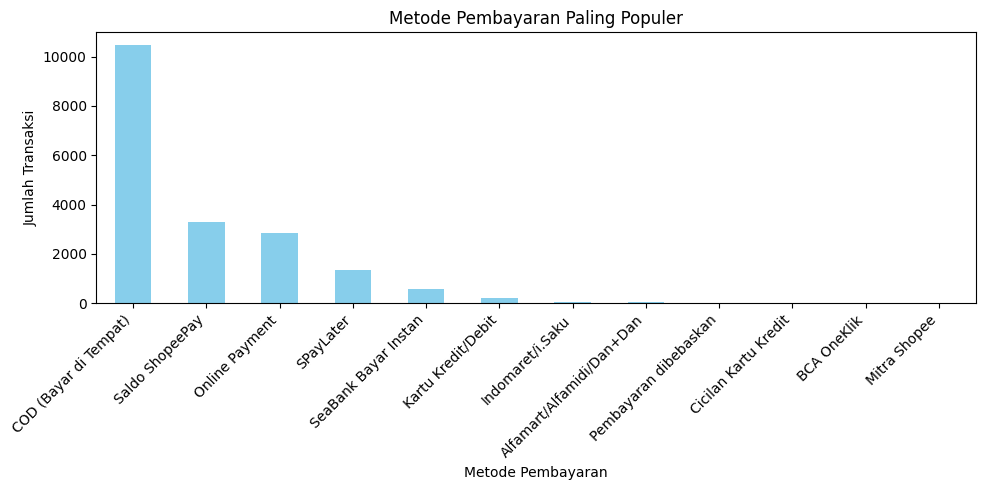

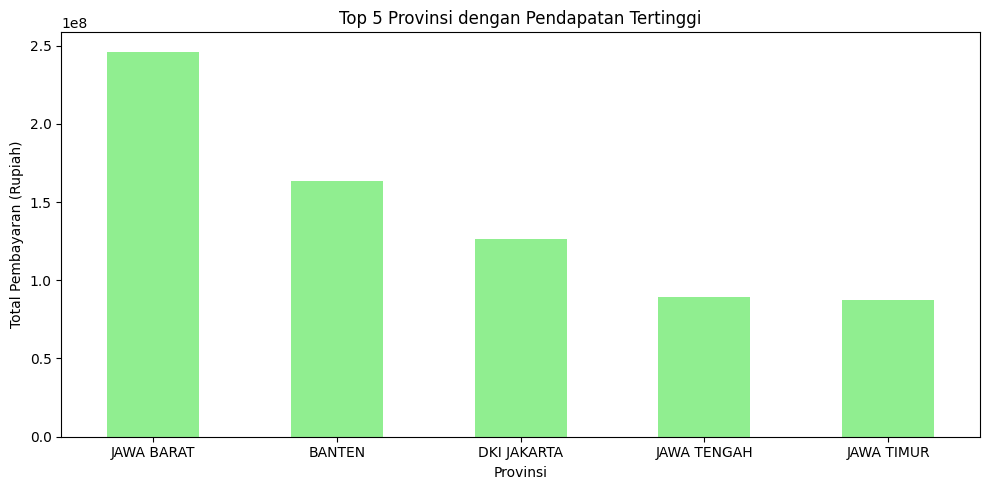

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
metode_bayar.plot(kind='bar', color='skyblue')
plt.title('Metode Pembayaran Paling Populer')
plt.xlabel('Metode Pembayaran')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
top_provinsi.plot(kind='bar', color='lightgreen')
plt.title('Top 5 Provinsi dengan Pendapatan Tertinggi')
plt.xlabel('Provinsi')
plt.ylabel('Total Pembayaran (Rupiah)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#INSIGHT

1. kategori produk
Kategori Seal/baut/roof adalah penghasil pendapatan terbesar, kemudian disusul oleh peralatan rumah tangga/UMKM seperti celengan dan mangkok sambal.
Sehingga toko di marketplace kemungkinan besar bergerak pada segementasi pasar b2b atau ke toko grosir perlengkapan barang rumah tangga, bukan hanya toko retail fashion.

2. Metode pembayaran
Metode pembayaran yang sering digunakan adalah COD, kemudian saldo shopeepay dan spaylatter.
sehingga pembeli di marketplace masih mengutamakan kepercayaan atau masih banyak pembeli yang belum memiliki akses online payment. namun disisi lain bank digital seperti shopeepay dan spaylatter menjadi opsi penggunaan non tunai paling kuat dibandingkan dengan onine payment lainnya.

3. Segmentasi wilayah
hasil menunjukan bahwa wilayah Jawa Barat berada di posisi 1 dengan Rp.246 juta yang kemudian di posisi selanjutnya adalah banteng dengan Rp.163 juta dan DKI jakarta dengan Rp. 126 juta.
sehingga untuk pengalaman pelanggan yaitu dapat dengan cara menempatkan Gudang Utama pada wilayah ibukota (Jabodetabek). Strategi ini dilakukan agar memotong biaya logistik (ongkos kirim) hingga lebih efisien dan mempercepat waktu pengiriman, yang pada akhirnya dapat meningkatkan loyalitas pelanggan dan volume penjualan.

In [12]:
df.to_csv('ecommerce_indonesia_clean.csv', index=False)